In [147]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance, gaussian_kde
from scipy.spatial.distance import jensenshannon
from sklearn.metrics import r2_score

In [148]:
master_df = pd.read_csv('master_df_final.csv')
questions = master_df['Question'].unique()
master_df = master_df[master_df['BeforeNumber'].between(0, 10) & master_df['AfterNumber'].between(0, 10)]
master_df["llm_avg"] = master_df[[f"run_{seed}" for seed in range(0,10)]].mean(axis=1).round(0).clip(0,10)
print(master_df.columns)
print(master_df.shape)

Index(['ID', 'Question', 'QuestionText', 'Topic', 'ValidResponse',
       'BeforeNumber', 'BeforeResponse', 'AfterNumber', 'AfterResponse',
       'GROUP', 'RACE', 'AGEBRACKET', 'EDUCATION', 'PARTYBEFORE', 'GENDER',
       'AGE', 'run_0', 'run_1', 'run_2', 'run_3', 'run_4', 'run_5', 'run_6',
       'run_7', 'run_8', 'run_9', 'llm_avg'],
      dtype='object')
(23094, 27)


In [149]:
# checking AI1R statements
#master_df = pd.read_csv('clean_data/question_level_master_dataset.csv')
demrep = master_df[(master_df['PARTYBEFORE']=='Democrat') | (master_df['PARTYBEFORE']=='Republican')]
extreme_data = demrep.groupby(['Question','PARTYBEFORE','BeforeNumber'])['ID'].count().reset_index()
extreme_data = extreme_data.rename(columns={'ID':'Count'})
extreme_data.head()

# Criterion A:  At least 15% of respondents identifying with each party (Democrats AND Republicans) selected
# the most extreme position (0 or 10 on a 0-10 scale), with these extremes positioned at opposite poles.
extremeQuestionsA = []
for question in questions:
    extremeQuestion = {}
    for party in ['Democrat', 'Republican']:
        subset = extreme_data[(extreme_data['Question']==question) & (extreme_data['PARTYBEFORE']==party)]
        total = subset['Count'].sum()
        prop0 = subset[subset['BeforeNumber'] == 0]['Count'].sum() / total
        prop10 = subset[subset['BeforeNumber'] == 10]['Count'].sum() / total
        left = subset[subset['BeforeNumber'] < 5]['Count'].sum()
        right = subset[subset['BeforeNumber'] > 5]['Count'].sum()
        if prop0 >= 0.15 and left > right:
            extremeQuestion[party] = 0
        elif prop10 >= 0.15 and right > left:
            extremeQuestion[party] = 10
    # assuming only one side can be extreme per party
        
    if len(extremeQuestion) == 2 and extremeQuestion['Democrat'] != extremeQuestion['Republican']:
        extremeQuestionsA.append(question)

print(f"Number of extreme questions: {len(extremeQuestionsA)}")

Number of extreme questions: 27


In [150]:
extreme_data = demrep.groupby(['Question','PARTYBEFORE','AfterNumber'])['ID'].count().reset_index()
extreme_data = extreme_data.rename(columns={'ID':'Count'})
extreme_data.head()

# Criterion A:  At least 15% of respondents identifying with each party (Democrats AND Republicans) selected
# the most extreme position (0 or 10 on a 0-10 scale), with these extremes positioned at opposite poles.
extremeQuestionsA = []
for question in questions:
    extremeQuestion = {}
    for party in ['Democrat', 'Republican']:
        subset = extreme_data[(extreme_data['Question']==question) & (extreme_data['PARTYBEFORE']==party)]
        total = subset['Count'].sum()
        prop0 = subset[subset['AfterNumber'] == 0]['Count'].sum() / total
        prop10 = subset[subset['AfterNumber'] == 10]['Count'].sum() / total
        left = subset[subset['AfterNumber'] < 5]['Count'].sum()
        right = subset[subset['AfterNumber'] > 5]['Count'].sum()
        if prop0 >= 0.15 and left > right:
            extremeQuestion[party] = 0
        elif prop10 >= 0.15 and right > left:
            extremeQuestion[party] = 10
    # assuming only one side can be extreme per party
        
    if len(extremeQuestion) == 2 and extremeQuestion['Democrat'] != extremeQuestion['Republican']:
        extremeQuestionsA.append(question)

print(f"Number of extreme questions: {len(extremeQuestionsA)}")

Number of extreme questions: 11


In [151]:
extreme_data = demrep.groupby(['Question','PARTYBEFORE','llm_avg'])['ID'].count().reset_index()
extreme_data = extreme_data.rename(columns={'ID':'Count'})
extreme_data.head()

# Criterion A:  At least 15% of respondents identifying with each party (Democrats AND Republicans) selected
# the most extreme position (0 or 10 on a 0-10 scale), with these extremes positioned at opposite poles.
extremeQuestionsA = []
for question in questions:
    extremeQuestion = {}
    for party in ['Democrat', 'Republican']:
        subset = extreme_data[(extreme_data['Question']==question) & (extreme_data['PARTYBEFORE']==party)]
        total = subset['Count'].sum()
        prop0 = subset[subset['llm_avg'] == 0]['Count'].sum() / total
        prop10 = subset[subset['llm_avg'] == 10]['Count'].sum() / total
        left = subset[subset['llm_avg'] < 5]['Count'].sum()
        right = subset[subset['llm_avg'] > 5]['Count'].sum()
        if prop0 >= 0.15 and left > right:
            extremeQuestion[party] = 0
        elif prop10 >= 0.15 and right > left:
            extremeQuestion[party] = 10
    # assuming only one side can be extreme per party
        
    if len(extremeQuestion) == 2 and extremeQuestion['Democrat'] != extremeQuestion['Republican']:
        extremeQuestionsA.append(question)

print(f"Number of extreme questions: {len(extremeQuestionsA)}")

Number of extreme questions: 5


In [152]:
# i want to calculate the difference in democrat and republican means for before, after, and llm
demrep_means = demrep.groupby(['Question','PARTYBEFORE']).agg({'BeforeNumber':'mean','AfterNumber':'mean','llm_avg':'mean'}).reset_index()
demrep_means_pivot = demrep_means.pivot(index='Question', columns='PARTYBEFORE', values=['BeforeNumber','AfterNumber','llm_avg'])
demrep_means_pivot['Before_Diff'] = abs(demrep_means_pivot['BeforeNumber']['Democrat'] - demrep_means_pivot['BeforeNumber']['Republican'])
demrep_means_pivot['After_Diff'] = abs(demrep_means_pivot['AfterNumber']['Democrat'] - demrep_means_pivot['AfterNumber']['Republican'])
demrep_means_pivot['LLM_Diff'] = abs(demrep_means_pivot['llm_avg']['Democrat'] - demrep_means_pivot['llm_avg']['Republican'])
demrep_means_pivot = demrep_means_pivot.reset_index()
#demrep_means_pivot[['Question','Before_Diff','After_Diff','LLM_Diff']]

In [153]:
import scipy.stats as stats

print("After vs LLM modellig the same depolarization effect:")
diff = stats.wilcoxon(demrep_means_pivot['After_Diff'], demrep_means_pivot['LLM_Diff'])
print(diff)
print("Before vs After showing depolarization effect:")
diff = stats.wilcoxon(demrep_means_pivot['Before_Diff'], demrep_means_pivot['After_Diff'])
print(diff)
print("Before vs LLM showing depolarization effect:")
diff = stats.wilcoxon(demrep_means_pivot['Before_Diff'], demrep_means_pivot['LLM_Diff'])
print(diff)

After vs LLM modellig the same depolarization effect:
WilcoxonResult(statistic=np.float64(53.0), pvalue=np.float64(3.2233060665021185e-10))
Before vs After showing depolarization effect:
WilcoxonResult(statistic=np.float64(54.0), pvalue=np.float64(3.6288838600739837e-10))
Before vs LLM showing depolarization effect:
WilcoxonResult(statistic=np.float64(581.0), pvalue=np.float64(0.947340221793219))


In [154]:
master_df['llm_avg_rounded'] = master_df['llm_avg'].round(0).clip(0,10)

In [155]:
print(stats.wilcoxon(master_df['AfterNumber'], master_df['llm_avg']))
print(stats.wilcoxon(master_df['BeforeNumber'], master_df['llm_avg']))
print(stats.wilcoxon(master_df['AfterNumber'], master_df['BeforeNumber']))

WilcoxonResult(statistic=np.float64(60404400.5), pvalue=np.float64(3.446934717190165e-70))
WilcoxonResult(statistic=np.float64(25646020.5), pvalue=np.float64(0.0))
WilcoxonResult(statistic=np.float64(59567874.5), pvalue=np.float64(0.27388746079304405))


###TRAINING ON LLM ERROR

In [156]:
results = []
for question in questions:
    q_df = master_df[master_df['Question'] == question]
    human  = q_df['AfterNumber']

    llm = q_df[f'llm_avg']

    ks_stat, ks_pval = ks_2samp(human, llm)
    w_dist = wasserstein_distance(human, llm)
    # choose shared bins, e.g. 0,1,2,...,10
    bins = np.arange(0, 11)  # or np.arange(0, 11+1) if using np.histogram

    # histograms -> counts per bin
    h_counts, _ = np.histogram(human, bins=bins, density=False)
    l_counts, _ = np.histogram(llm, bins=bins, density=False)

    # convert to probabilities
    p_h = h_counts / h_counts.sum()
    p_l = l_counts / l_counts.sum()

    js = jensenshannon(p_h, p_l)

    wc = stats.wilcoxon(human, llm)
    
    results.append({
        'question': question,
        'human_shift': human.mean(),
        'llm_mean_shift': llm.mean(),
        'ks_D': ks_stat,
        'ks_p': ks_pval,
        'wasserstein': w_dist,
        'js_mean': js,
        'wilcoxon_stat': wc.statistic,
        'wilcoxon_p': wc.pvalue
        
    })
results_df = pd.DataFrame(results)
results_df.head()

,question,human_shift,llm_mean_shift,ks_D,ks_p,wasserstein,js_mean,wilcoxon_stat,wilcoxon_p
0,Q1,5.877551,4.212245,0.271429,2.761776e-16,1.665306,0.302668,12033.5,2.419154e-37
1,Q2A,3.419162,4.504990,0.253493,1.514286e-14,1.221557,0.232345,18557.5,1.015415e-18
2,Q2B,8.738523,8.045908,0.243513,1.911537e-13,0.692615,0.158689,12763.0,1.161877e-14
3,Q2C,6.131313,6.589899,0.179798,2.092355e-07,0.692929,0.292980,34634.0,7.467881e-05
4,Q2D,7.618290,6.994036,0.198807,4.148595e-09,0.691849,0.237614,25450.0,1.972595e-10


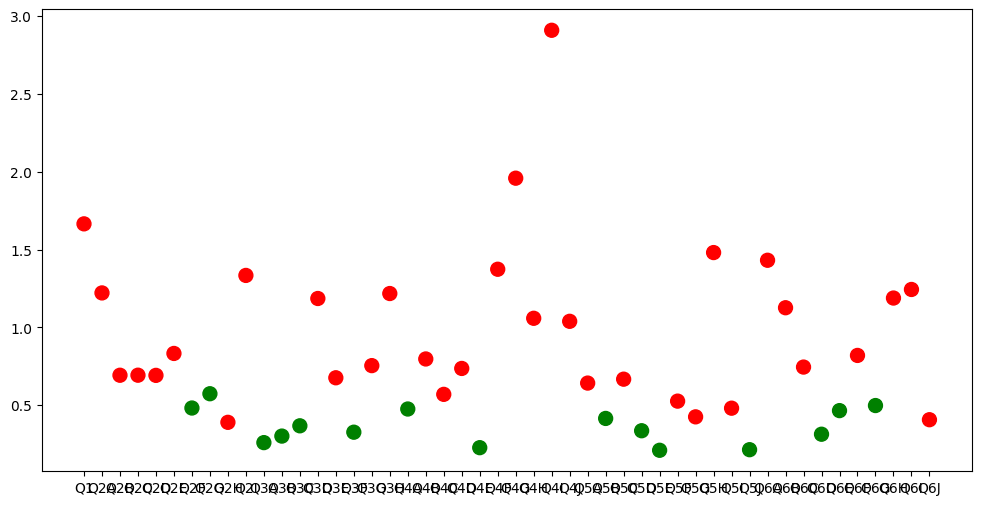

In [157]:
# get significant questions
results_df['no_sig_diff'] = results_df['wilcoxon_p'] > 0.05
plt.figure(figsize=(12, 6))
plt.scatter(results_df['question'], results_df['wasserstein'], s=100, c=results_df['no_sig_diff'].map({True: 'green', False: 'red'}))

In [158]:
# join results to master df to get topics
master_with_results = results_df.merge(master_df, left_on='question', right_on='Question', how='left')
master_with_results[['Question','Topic','no_sig_diff']].drop_duplicates().groupby(['Topic','no_sig_diff']).count()

Question
Topic           no_sig_diff          
Climate Change  False               4
                True                4
Democracy       False               1
Global Position False               7
                True                3
Healthcare      False               6
                True                4
Immigration     False               7
                True                2
Taxes           False               8
                True                2

In [159]:
master_df.head()

,ID,Question,QuestionText,Topic,ValidResponse,BeforeNumber,BeforeResponse,AfterNumber,AfterResponse,GROUP,...,run_2,run_3,run_4,run_5,run_6,run_7,run_8,run_9,llm_avg,llm_avg_rounded
0,0,Q1,How poorly or well would you say the system of...,Democracy,True,5,In the middle,9,Very strongly favor,1,...,4,6,4,4,6,4,6,6,5.0,5.0
1,17,Q1,How poorly or well would you say the system of...,Democracy,True,7,Moderately favor,9,Very strongly favor,1,...,8,6,6,6,6,6,6,6,6.0,6.0
2,127,Q1,How poorly or well would you say the system of...,Democracy,True,5,In the middle,7,Moderately favor,1,...,4,6,4,4,4,6,6,6,5.0,5.0
3,173,Q1,How poorly or well would you say the system of...,Democracy,True,6,Slightly favor,7,Moderately favor,1,...,7,7,7,5,7,5,7,7,6.0,6.0
4,189,Q1,How poorly or well would you say the system of...,Democracy,True,7,Moderately favor,9,Very strongly favor,1,...,8,6,8,6,6,6,6,8,7.0,7.0


In [195]:
# print out questions with no significant difference
no_sig_questions = results_df[results_df['no_sig_diff'] == True]['question'].tolist()
print(no_sig_questions)

['Q2F', 'Q2G', 'Q3A', 'Q3B', 'Q3C', 'Q3F', 'Q4A', 'Q4E', 'Q5B', 'Q5D', 'Q5E', 'Q5J', 'Q6D', 'Q6E', 'Q6G']


In [196]:
# ok now we want to train a model to predict how far off the llm is from humans
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

master_df['llm_avg_raw'] = master_df[[f"run_{seed}" for seed in range(0,10)]].mean(axis=1)
master_df['RACE'] = master_df['RACE'].apply(lambda x: x.replace(' ', '_').replace(',', '').replace('-', '_'))
master_df['EDUCATION'] = master_df['EDUCATION'].apply(lambda x: x.replace(' ', '_'))
master_df['AGEBRACKET'] = master_df['AGEBRACKET'].apply(lambda x: x.replace(' ', '_').replace('-', '_').replace('+', 'plus'))

#for col in ['RACE','PARTYBEFORE','EDUCATION','AGEBRACKET']:
    #print(q_df[col].value_counts())
# remove dummies with demographic data < #10
    
corrected = {}
formula = ("shift ~ RACE_Asian_non_Hispanic + RACE_Black_non_Hispanic + "
           "RACE_Hispanic + RACE_Other_non_Hispanic + RACE_White_non_Hispanic + "
           "AGEBRACKET_30_44 + AGEBRACKET_45_59 + AGEBRACKET_60plus + "
           "EDUCATION_HS_graduate_or_equivalent + EDUCATION_No_HS_diploma + "
           "EDUCATION_Some_college + PARTYBEFORE_Independent + "
           "PARTYBEFORE_Republican + GENDER_Male + 1")


corrected_df = pd.DataFrame(columns=['ID','Question','Corrected_LLM'])
models = {}
for question in questions:
    qdf = master_df[master_df['Question'] == question]
    X = qdf[['RACE', 'AGEBRACKET', 'EDUCATION', 'PARTYBEFORE', 'GENDER']].copy()
    X = pd.get_dummies(X, drop_first=True, dtype=int)
    X['Group'] = qdf['GROUP']
    # target is how far off the llm shift is from the human shift
    y = qdf['AfterNumber'] - qdf['llm_avg_raw']
    df_run = X.copy()
    scaler = StandardScaler()

    df_run['shift'] = scaler.fit_transform(y.values.reshape(-1,1))

    model = smf.ols(formula=formula, data=df_run).fit(cov_type="cluster", cov_kwds={"groups": df_run["Group"]})
    y_preds = model.predict(df_run)

    corrected_df = pd.concat([corrected_df, pd.DataFrame({
        'ID': qdf['ID'],
        'Question': qdf['Question'],
        'Corrected_LLM': (scaler.inverse_transform(y_preds.values.reshape(-1,1)).flatten() + qdf['llm_avg_raw'].values).round().clip(0,10)
    })], ignore_index=True)
    # get r squared
    r_squared = model.rsquared
    
    models[question] = {
        'model': model,
        'r_squared': r_squared
    }

model_df = pd.DataFrame.from_dict(models, orient='index')

/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_25836/3918698442.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corrected_df = pd.concat([corrected_df, pd.DataFrame({


In [197]:
# ok now we want to train a model to predict how far off the llm is from humans
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler

master_df['llm_avg_raw'] = master_df[[f"run_{seed}" for seed in range(0,10)]].mean(axis=1)
master_df['RACE'] = master_df['RACE'].apply(lambda x: x.replace(' ', '_').replace(',', '').replace('-', '_'))
master_df['EDUCATION'] = master_df['EDUCATION'].apply(lambda x: x.replace(' ', '_'))
master_df['AGEBRACKET'] = master_df['AGEBRACKET'].apply(lambda x: x.replace(' ', '_').replace('-', '_').replace('+', 'plus'))

#for col in ['RACE','PARTYBEFORE','EDUCATION','AGEBRACKET']:
    #print(q_df[col].value_counts())
# remove dummies with demographic data < #10
    
corrected = {}


corrected_df = pd.DataFrame(columns=['ID','Question','Corrected_LLM'])
models = {}
for question in questions:
    
    qdf = master_df[master_df['Question'] == question]
    X = qdf[['RACE', 'AGEBRACKET', 'EDUCATION', 'PARTYBEFORE', 'GENDER']].copy()
    X = pd.get_dummies(X, drop_first=True, dtype=int)
    X['Group'] = qdf['GROUP']
    # target is how far off the llm shift is from the human shift
    y = qdf['AfterNumber'] - qdf['llm_avg_raw']
    df_run = X.copy()
    scaler = StandardScaler()

    df_run['shift'] = scaler.fit_transform(y.values.reshape(-1,1))

    model = smf.ols(formula=formula, data=df_run).fit(cov_type="cluster", cov_kwds={"groups": df_run["Group"]})
    y_preds = model.predict(df_run)

    corrected_df = pd.concat([corrected_df, pd.DataFrame({
        'ID': qdf['ID'],
        'Question': qdf['Question'],
        'Corrected_LLM': (scaler.inverse_transform(y_preds.values.reshape(-1,1)).flatten() + qdf['llm_avg_raw'].values).round().clip(0,10)
    })], ignore_index=True)
    # get r squared
    r_squared = model.rsquared
    
    models[question] = {
        'model': model,
        'r_squared': r_squared
    }

model_df = pd.DataFrame.from_dict(models, orient='index')

/var/folders/qw/dj7vjbyd6kb8q83q6chjb9m00000gn/T/ipykernel_25836/3138557928.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corrected_df = pd.concat([corrected_df, pd.DataFrame({


In [201]:
model_df.head()

,model,r_squared
Q1,<statsmodels.regression.linear_model.Regressio...,0.053417
Q2A,<statsmodels.regression.linear_model.Regressio...,0.092933
Q2B,<statsmodels.regression.linear_model.Regressio...,0.031133
Q2C,<statsmodels.regression.linear_model.Regressio...,0.046196
Q2D,<statsmodels.regression.linear_model.Regressio...,0.045527


In [187]:
import statsmodels.formula.api as smf
from sklearn.metrics import r2_score

# 1. Use .copy() to avoid SettingWithCopyWarning
qdf = master_df[master_df['Question'] == "Q2C"].copy()
qdf["shift"] = qdf['AfterNumber'] - qdf['llm_avg_raw']

# Note: I'm removing the global scaler here. 
# If you want to scale, it's better to scale the predictors, not the target.

r2arr = []
groups = qdf['GROUP'].unique()

for group in groups:
    train_df = qdf[qdf['GROUP'] != group]
    test_df = qdf[qdf['GROUP'] == group]

    formula = "shift ~ C(RACE) + C(AGEBRACKET) + C(EDUCATION) + C(PARTYBEFORE) + C(GENDER)"
    
    try:
        # Fit the model
        model = smf.mixedlm(formula, train_df, groups=train_df["GROUP"]).fit()

        # Predict (Fixed effects only)
        preds = model.predict(test_df) 
        
        # Calculate R2
        r2 = r2_score(test_df['shift'], preds)
        r2arr.append(r2)
    except Exception as e:
        print(f"Skipping group {group} due to error: {e}")

print(f"Average Cross-Validated R2: {sum(r2arr)/len(r2arr)}")

Average Cross-Validated R2: -0.33308954505959176


In [200]:
from sklearn.model_selection import GroupKFold
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Setup Data
qdf = master_df[master_df['Question'] == "Q4E"].copy()
qdf["shift"] = qdf['AfterNumber'] - qdf['llm_avg_raw']

features = ['RACE', 'AGEBRACKET', 'EDUCATION', 'PARTYBEFORE', 'GENDER']
X = qdf[features]
y = qdf['shift']
groups = qdf['GROUP']

# 2. Setup 10-fold CV (40 groups / 10 folds = 4 groups per test set)
gkf = GroupKFold(n_splits=10)

rf_pipeline = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), features)
    ])),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

results = []

# 3. Iterate through folds (each 'test_idx' contains 4 unique groups)
for train_idx, test_idx in gkf.split(X, y, groups=groups):
    train_df = qdf.iloc[train_idx].copy()
    test_df = qdf.iloc[test_idx].copy()
    
    # --- Mixed LM ---
    formula = "shift ~ C(RACE) + C(AGEBRACKET) + C(EDUCATION) + C(PARTYBEFORE) + C(GENDER)"
    try:
        mlm_model = smf.mixedlm(formula, train_df, groups=train_df["GROUP"]).fit()
        mlm_shift_preds = mlm_model.predict(test_df)
    except:
        mlm_shift_preds = np.repeat(train_df['shift'].mean(), len(test_df))

    # --- Random Forest ---
    rf_pipeline.fit(train_df[features], train_df['shift'])
    rf_shift_preds = rf_pipeline.predict(test_df[features])

    # --- Rescale & Round to AfterNumber ---
    y_true = test_df['AfterNumber']
    
    mlm_after_preds = (mlm_shift_preds + test_df['llm_avg_raw']).round()
    rf_after_preds = (rf_shift_preds + test_df['llm_avg_raw']).round()
    
    # Baseline: Just using LLM raw average
    baseline_preds = test_df['llm_avg_raw'].round()

    results.append({
        'MLM_MAE': mean_absolute_error(y_true, mlm_after_preds),
        'RF_MAE': mean_absolute_error(y_true, rf_after_preds),
        'Baseline_MAE': mean_absolute_error(y_true, baseline_preds),
        'MLM_R2': r2_score(y_true, mlm_after_preds),
        'RF_R2': r2_score(y_true, rf_after_preds)
    })

# 4. Results
res_df = pd.DataFrame(results)
print("--- Comparison (MAE in original scale) ---")
print(res_df[['Baseline_MAE', 'MLM_MAE', 'RF_MAE']].mean())
print("\n--- Comparison (R2) ---")
print(res_df[['MLM_R2', 'RF_R2']].mean())

/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/mabelwylie/Documents/DISCO_

--- Comparison (MAE in original scale) ---
Baseline_MAE    1.678902
MLM_MAE         1.740157
RF_MAE          1.959765
dtype: float64

--- Comparison (R2) ---
MLM_R2   -0.233018
RF_R2    -0.353224
dtype: float64


In [202]:
import statsmodels.formula.api as smf
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import numpy as np

master_df['llm_avg_raw'] = master_df[[f"run_{seed}" for seed in range(0,10)]].mean(axis=1)


corrected_list = []
summary_results = {}
formula = "shift ~ C(RACE) + C(AGEBRACKET) + C(EDUCATION) + C(PARTYBEFORE) + C(GENDER)"

for question in questions:
    qdf = master_df[master_df['Question'] == question].copy()
    qdf['shift'] = qdf['AfterNumber'] - qdf['llm_avg_raw']
    
    # --- CROSS-VALIDATION (The "Evidence") ---
    # Split into 10 folds (4 groups each for 40 groups)
    gkf = GroupKFold(n_splits=10)
    cv_maes = []
    cv_baselines = []
    
    for train_idx, test_idx in gkf.split(qdf, qdf['shift'], groups=qdf['GROUP']):
        train_cv = qdf.iloc[train_idx]
        test_cv = qdf.iloc[test_idx]
        
        try:
            # Fit on training groups, predict for the 4 unseen groups
            cv_model = smf.mixedlm(formula, train_cv, groups=train_cv["GROUP"]).fit()
            cv_shift_preds = cv_model.predict(test_cv)
            
            # Rescale and round to original scale
            y_true = test_cv['AfterNumber']
            y_pred = (cv_shift_preds + test_cv['llm_avg_raw']).round().clip(0,10)
            baseline = test_cv['llm_avg_raw'].round().clip(0,10)
            
            cv_maes.append(mean_absolute_error(y_true, y_pred))
            cv_baselines.append(mean_absolute_error(y_true, baseline))
        except:
            continue

    # --- PRODUCTION (The "Correction") ---
    # Fit on all 40 groups to get the best correction for your current data
    final_model = smf.mixedlm(formula, qdf, groups=qdf["GROUP"]).fit()
    
    # We use fittedvalues here because it includes the Group-specific random effect
    qdf['Corrected_LLM'] = (final_model.fittedvalues + qdf['llm_avg_raw']).round().clip(0,10)
    
    # Append to global corrected dataframe
    corrected_list.append(qdf[['ID', 'Question', 'Corrected_LLM']])
    
    # Store metrics for summary_df
    summary_results[question] = {
        'CV_MAE': np.mean(cv_maes),
        'Baseline_MAE': np.mean(cv_baselines),
        'Overall_R2': r2_score(qdf['AfterNumber'], qdf['Corrected_LLM']),
        'Model': final_model
    }

# Combine results
corrected_df = pd.concat(corrected_list, ignore_index=True)
model_summary_df = pd.DataFrame.from_dict(summary_results, orient='index')

print(model_summary_df[['Baseline_MAE', 'CV_MAE', 'Overall_R2']])

/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/mabelwylie/Documents/DISCO_

     Baseline_MAE    CV_MAE  Overall_R2
Q1       2.301704  1.850670   -0.164513
Q2A      2.182515  1.889844    0.416805
Q2B      1.403797  1.269748   -0.065729
Q2C      2.010611  2.024818    0.305845
Q2D      1.713922  1.667725    0.172014
Q2E      2.062588  1.922784   -0.038653
Q2F      2.065707  2.139697    0.090895
Q2G      2.488874  2.487145   -0.146694
Q2H      1.368118  1.332196    0.487237
Q2I      2.418115  2.229898    0.312743
Q3A      1.346509  1.432589    0.676834
Q3B      1.566040  1.613001    0.525457
Q3C      1.752213  1.795846    0.404052
Q3D      1.910339  1.767651    0.631502
Q3E      1.793176  1.849691    0.552088
Q3F      1.422043  1.444290    0.439074
Q3G      2.072071  2.105556    0.380532
Q3H      2.123895  1.928699    0.414721
Q4A      2.509176  2.490824   -0.051958
Q4B      2.365294  2.450353    0.318431
Q4C      2.586280  2.547947    0.062833
Q4D      1.866333  1.922795    0.329178
Q4E      1.678902  1.726392    0.096371
Q4F      2.403323  2.045361    0.143508


/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/mabelwylie/Documents/DISCO_Semester_Project/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(


In [203]:
# combine corrected df with master df
final_df = master_df.merge(corrected_df, on=['ID','Question'])

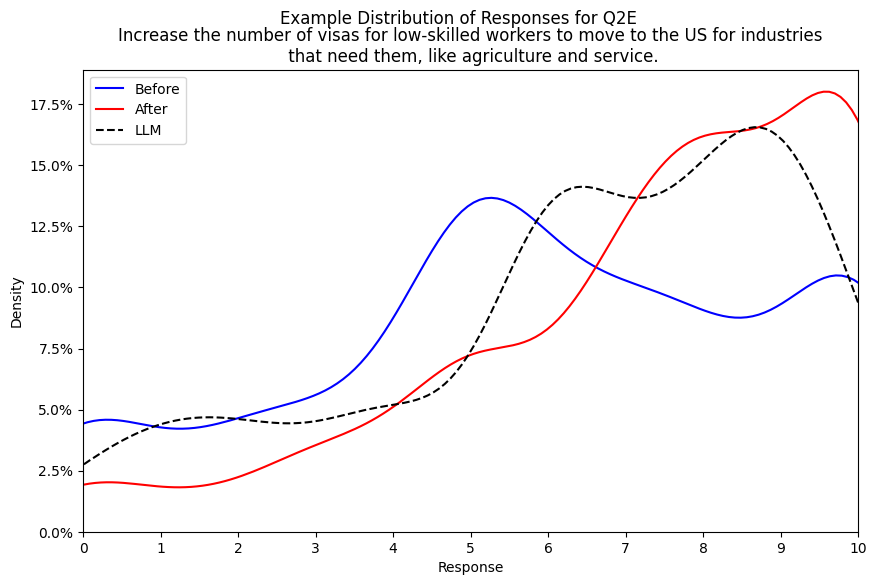

In [204]:
# plot before, after, llm, corrected llm for a question
question_to_plot = questions[5]  # change index to plot different questions
import matplotlib.ticker as mtick

qdf = final_df[final_df['Question'] == question_to_plot]
plt.figure(figsize=(10, 6))
ax = sns.kdeplot(qdf['BeforeNumber'], label='Before', color='blue')
sns.kdeplot(qdf['AfterNumber'], label='After', color='red')
sns.kdeplot(qdf['llm_avg'], label='LLM', color='black', linestyle='--')
#sns.kdeplot(qdf['Corrected_LLM'], label='Corrected LLM', color='orange')
plt.suptitle('Example Distribution of Responses for Q2E')
plt.title('Increase the number of visas for low-skilled workers to move to the US for industries\n that need them, like agriculture and service.')
plt.xlim(0,10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax = 1))
# change y ticks to percemtage
plt.xlabel('Response')
plt.ylabel('Density')
plt.xticks(range(0,11))
plt.legend()
plt.savefig('figures/example_distribution_Q2E_not_correct.pdf')

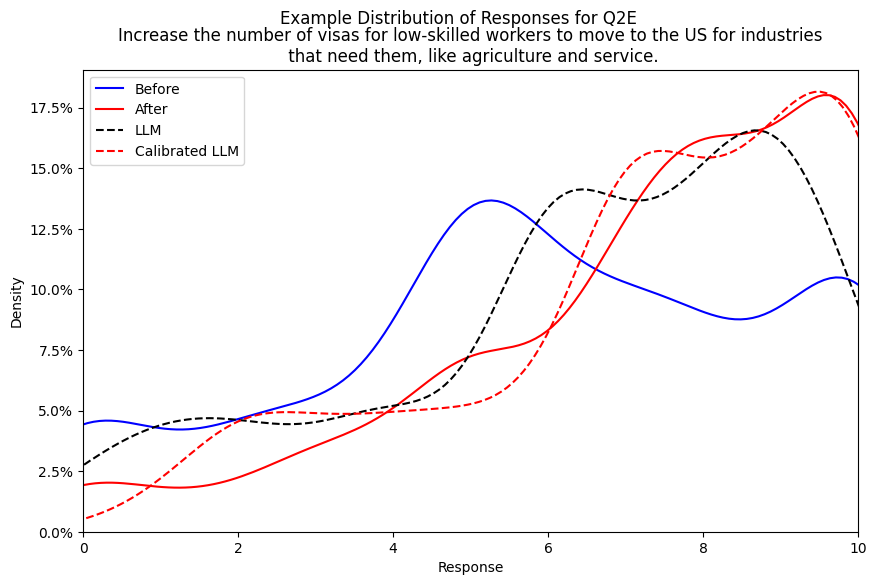

In [205]:
# plot before, after, llm, corrected llm for a question
question_to_plot = questions[5]  # change index to plot different questions
import matplotlib.ticker as mtick

qdf = final_df[final_df['Question'] == question_to_plot]
plt.figure(figsize=(10, 6))
ax = sns.kdeplot(qdf['BeforeNumber'], label='Before', color='blue')
sns.kdeplot(qdf['AfterNumber'], label='After', color='red')
sns.kdeplot(qdf['llm_avg'], label='LLM', color='black', linestyle='--')
sns.kdeplot(qdf['Corrected_LLM'], label='Calibrated LLM', color='red', linestyle='--')
plt.suptitle('Example Distribution of Responses for Q2E')
plt.title('Increase the number of visas for low-skilled workers to move to the US for industries\n that need them, like agriculture and service.')
plt.xlim(0,10)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax = 1))
# change y ticks to percemtage
plt.xlabel('Response')
plt.ylabel('Density')
plt.legend()
plt.savefig('figures/example_distribution_Q2E_correct.pdf')

In [206]:
results = []
for question in questions:
    q_df = final_df[final_df['Question'] == question]
    human  = q_df['AfterNumber']

    llm = q_df[f'Corrected_LLM']

    ks_stat, ks_pval = ks_2samp(human, llm)
    w_dist = wasserstein_distance(human, llm)
    # choose shared bins, e.g. 0,1,2,...,10
    bins = np.arange(0, 11)  # or np.arange(0, 11+1) if using np.histogram

    # histograms -> counts per bin
    h_counts, _ = np.histogram(human, bins=bins, density=False)
    l_counts, _ = np.histogram(llm, bins=bins, density=False)

    # convert to probabilities
    p_h = h_counts / h_counts.sum()
    p_l = l_counts / l_counts.sum()

    js = jensenshannon(p_h, p_l)

    wc = stats.wilcoxon(human, llm)
    
    results.append({
        'question': question,
        'human_shift': human.mean(),
        'llm_mean_shift': llm.mean(),
        'ks_D': ks_stat,
        'ks_p': ks_pval,
        'wasserstein': w_dist,
        'js_mean': js,
        'wilcoxon_stat': wc.statistic,
        'wilcoxon_p': wc.pvalue
        
    })
results_df = pd.DataFrame(results)
results_df.head()

,question,human_shift,llm_mean_shift,ks_D,ks_p,wasserstein,js_mean,wilcoxon_stat,wilcoxon_p
0,Q1,5.877551,5.879592,0.087755,0.045898,0.410204,0.162767,40764.0,0.951435
1,Q2A,3.419162,3.608782,0.139721,0.000111,0.660679,0.254441,29982.0,0.027252
2,Q2B,8.738523,8.586826,0.067864,0.198956,0.179641,0.101400,19000.0,0.075758
3,Q2C,6.131313,6.135354,0.143434,0.000074,0.460606,0.153019,41788.5,0.818997
4,Q2D,7.618290,7.578529,0.083499,0.059939,0.282306,0.154652,35500.5,0.809848


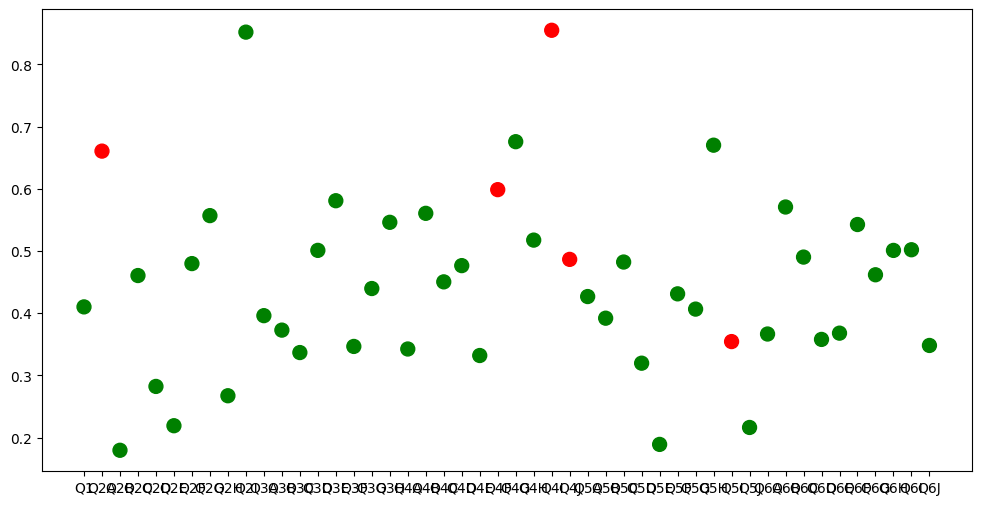

In [207]:
# get significant questions
results_df['no_sig_diff'] = results_df['wilcoxon_p'] > 0.05
plt.figure(figsize=(12, 6))
plt.scatter(results_df['question'], results_df['wasserstein'], s=100, c=results_df['no_sig_diff'].map({True: 'green', False: 'red'}))

In [ ]:
final_df['delta_human'] = final_df['AfterNumber'] - final_df['BeforeNumber']
final_df['delta_llm'] = final_df['Corrected_LLM'] - final_df['BeforeNumber']

In [ ]:
results = []
for question in questions:
    q_df = final_df[final_df['Question'] == question]
    human  = q_df['delta_human']

    llm = q_df['delta_llm']

    ks_stat, ks_pval = ks_2samp(human, llm)
    w_dist = wasserstein_distance(human, llm)
    # choose shared bins, e.g. 0,1,2,...,10
    bins = np.arange(-10, 11)  # or np.arange(0, 11+1) if using np.histogram

    # histograms -> counts per bin
    h_counts, _ = np.histogram(human, bins=bins, density=False)
    l_counts, _ = np.histogram(llm, bins=bins, density=False)

    # convert to probabilities
    p_h = h_counts / h_counts.sum()
    p_l = l_counts / l_counts.sum()

    js = jensenshannon(p_h, p_l)

    wc = stats.wilcoxon(human, llm)
    
    results.append({
        'question': question,
        'human_delta': human.mean(),
        'llm_corrected_delta': llm.mean(),
        'ks_D': ks_stat,
        'ks_p': ks_pval,
        'wasserstein': w_dist,
        'js_mean': js,
        'wilcoxon_stat': wc.statistic,
        'wilcoxon_p': wc.pvalue
        
    })
results_df = pd.DataFrame(results)
results_df.head()

,question,human_delta,llm_corrected_delta,ks_D,ks_p,wasserstein,js_mean,wilcoxon_stat,wilcoxon_p
0,Q1,1.346939,1.351020,0.185714,8.438911e-08,1.130612,0.354422,41992.5,0.886326
1,Q2A,-1.564870,-1.393214,0.225549,1.404985e-11,1.193613,0.369708,30412.5,0.046013
2,Q2B,1.205589,1.041916,0.207585,7.347790e-10,0.934132,0.351242,18875.0,0.050490
3,Q2C,0.351515,0.351515,0.177778,3.002299e-07,1.268687,0.346291,42779.0,0.808302
4,Q2D,1.234592,1.232604,0.258449,3.609788e-15,1.222664,0.404797,37032.0,0.884534


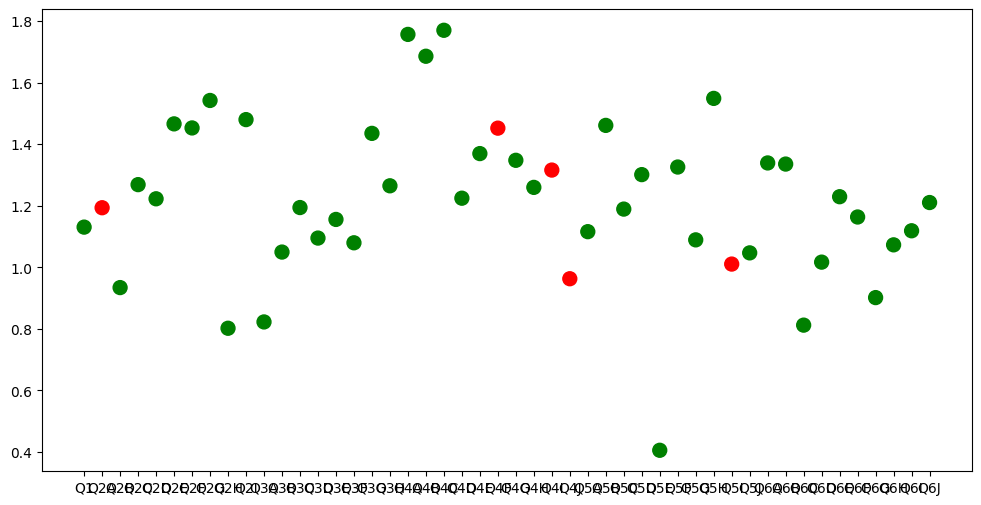

In [ ]:
# get significant questions
results_df['no_sig_diff'] = results_df['wilcoxon_p'] > 0.05
plt.figure(figsize=(12, 6))
plt.scatter(results_df['question'], results_df['wasserstein'], s=100, c=results_df['no_sig_diff'].map({True: 'green', False: 'red'}))

In [ ]:
# join results to master df to get topics
master_with_results = results_df.merge(master_df, left_on='question', right_on='Question', how='left')
master_with_results[['Question','Topic','no_sig_diff']].drop_duplicates().groupby(['Topic','no_sig_diff']).count()

Question
Topic           no_sig_diff          
Climate Change  True                8
Democracy       True                1
Global Position True               10
Healthcare      False               1
                True                9
Immigration     False               1
                True                8
Taxes           False               3
                True                7

In [ ]:
questions_to_leave_out = results_df[results_df['no_sig_diff'] == False]['question'].tolist()
final_df_cleaned = final_df[~final_df['Question'].isin(questions_to_leave_out)]
final_df_cleaned.to_csv('final_df_corrected_cleaned.csv', index=False)

In [ ]:
# maybe do leave one out cross validation to see how well the model generalizes